# Deep Hedging - Testing & Ideas

### Ideas

- Transaction costs
- Deep hedging (batches with different models (Heston, G2++, GARCH, etc.))
- Other risk measure (for optimizing final pnl)
- Time dependant risk measure (risk managed paths pnl)

# Deep Hedging Agent

___
### Transaction Costs

In order to make the simulation of deep hedging more realistic, a transaction cost will be applied to each rebalancing decision the agent makes. The transaction cost is defined as followed:
$$
\text{TC}_t = S_t \ \kappa \ |\delta _t - \delta _{t-1}|
$$
where $\kappa$ is the constant transaction cost rate. (As reported in Bazzana and Collini (2020), transaction cost on the S&P 500 are around 0.047%).
Note that this is based on an assumption that transaction cost are equivalent for buying or selling the underlying asset.

___
### Deep Hedging Agent Set Up

Based on te work of Buehler and al. (2019), the deep hedging agent will be based on the following properties. 
- Feedforward Neural Network
- 2 hidden layers, 64 neurons per layer
- ReLU activation function
- Sigmoid output activation function
- 3 features, for each time $t < T$ 
    - Underlying asset price $S_t$ and the time to maturity $T-t$, which are time invariant (can be computed at $t_0$ given a simulated asset path)
    - Previous delta $\delta_{t-1}$, which helps the agent learn the transaction cost policy

Based on Buehler and al. (2019)

___
### Deep Hedging Agent

In [47]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
class DeepHedging(nn.Module):
    """
    Feed forward neural network with 2 hidden layers.
    - 3 inputs: log-moneyness, time to maturity, previous delta δ_{t-1}
    - Activation function: ReLU
    - Output activation function: Sigmoid (ensures delta in [0,1])
    """
    def __init__(self, K, r, T, kappa=0.0, num_features=3, hidden_size=64):
        super().__init__()
        self.K = K
        self.r = r
        self.T = T
        self.kappa = kappa
        self.num_features = num_features
        self.hidden_size = hidden_size

        self.net = nn.Sequential(
            nn.Linear(num_features, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, hidden_size), nn.ReLU(),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

    def build_features(self, S):
        """Precompute time-invariant features: log-moneyness and ttm."""
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness = torch.log(S[:, :-1] / self.K)             # (N_paths, N_steps)
        ttm = torch.linspace(self.T, 0, N_steps + 1)[:-1]         # (N_steps,)
        ttm_grid = ttm.unsqueeze(0).expand(N_paths, -1)            # (N_paths, N_steps)
        
        return log_moneyness, ttm_grid

    def compute_deltas(self, S):
        """
        Sequential delta computation: at each step t, feed (log-moneyness_t, ttm_t, δ_{t-1})
        so the NN can explicitly condition on the previous position when deciding to rebalance.
        δ_{t-1} is detached to avoid backprop through the sequential dependency (efficiency).
        """
        N_paths, N_steps_plus1 = S.shape
        N_steps = N_steps_plus1 - 1
        log_moneyness, ttm_grid = self.build_features(S)

        delta_prev = torch.zeros(N_paths)                          # initial position is 0
        deltas = []
        for t in range(N_steps):
            feat = torch.stack([log_moneyness[:, t],
                                ttm_grid[:, t],
                                delta_prev], dim=1)                # (N_paths, 3)
            delta_t = self(feat).squeeze(1)                        # (N_paths,)
            deltas.append(delta_t)
            delta_prev = delta_t.detach()                          # detach: treat prev delta as input, not backprop through it

        return torch.stack(deltas, dim=1)                          # (N_paths, N_steps)

    def calc_pnl(self, S, deltas, initial_portfolio):
        """
        S : (N_paths, N_steps + 1)
        deltas : (N_paths, N_steps)
        """
        N_paths, N_steps = deltas.shape
        dt = self.T / N_steps

        ttm = torch.linspace(self.T, 0, S.shape[1])
        compound = torch.exp(self.r * (self.T - ttm[1:]))
        dS = S[:, 1:] - S[:, :-1] * torch.exp(torch.tensor(self.r * dt))
        hedging_pnl = torch.sum(deltas * dS * compound, dim=1)

        # transaction costs: κ * |Δδ_t| * S_t, compounded to maturity
        prev_deltas = torch.cat([torch.zeros(N_paths, 1), deltas[:, :-1]], dim=1)
        change_deltas = torch.abs(deltas - prev_deltas)
        transaction_costs = self.kappa * torch.sum(change_deltas * S[:, :-1] * compound, dim=1)

        initial_value_maturity = initial_portfolio * torch.exp(torch.tensor(self.r * self.T))
        payoff = torch.relu(S[:, -1] - self.K)

        pnl = initial_value_maturity + hedging_pnl - payoff - transaction_costs
        return pnl, transaction_costs

    # --- Risk measures ---

    def cvar_loss(self, pnl, alpha=0.95):
        losses = -pnl
        var = torch.quantile(losses, alpha).detach()
        return var + (1 / (1 - alpha)) * torch.mean(torch.relu(losses - var))

    def mse_loss(self, pnl):
        return torch.mean(pnl ** 2)

    def smse_loss(self, pnl):
        losses = -pnl[pnl < 0]
        #losses = -pnl[pnl > 0]
        if losses.numel() == 0:
            return torch.tensor(0.0)
        return torch.mean(losses ** 2)
        #return torch.mean(losses)

    def variance_loss(self, pnl):
        return torch.var(pnl)

    # --- Training ---

    def train_deep_hedger(self, S, initial_portfolio, risk='cvar', alpha=0.95,
                          lr=1e-3, n_epochs=500):
        """Train on simulated paths S (numpy array)."""
        paths = torch.tensor(S, dtype=torch.float32)
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)

        print(f"\nTraining | risk={risk} | alpha={alpha} | kappa={self.kappa} | hidden={self.hidden_size} | lr={lr} | epochs={n_epochs}")
        for epoch in range(n_epochs + 1):
            optimizer.zero_grad()
            deltas = self.compute_deltas(paths)                    # sequential: uses δ_{t-1} as feature
            pnl, tc = self.calc_pnl(paths, deltas, initial_portfolio)

            if risk == 'cvar':
                loss = self.cvar_loss(pnl, alpha)
            elif risk == 'mse':
                loss = self.mse_loss(pnl)
            elif risk == 'smse':
                loss = self.smse_loss(pnl)
            elif risk == 'variance':
                loss = self.variance_loss(pnl)
            else:
                raise ValueError(f"Unknown risk measure: {risk}")

            loss.backward()
            optimizer.step()

            if epoch % 100 == 0:
                print(f"Epoch {epoch:4d} | loss = {loss.item():.4f} | mean P&L = {pnl.mean().item():.4f} | std = {pnl.std().item():.4f} | mean TC = {tc.mean().item():.4f}")

    # --- Testing ---

    def test_deephedging(self, S, initial_portfolio, risk='cvar', alpha=0.95):
        """Evaluate trained model on out-of-sample paths S (numpy array)."""
        S_test = torch.tensor(S, dtype=torch.float32)
        N_paths, N_steps_plus1 = S_test.shape
        N_steps = N_steps_plus1 - 1

        self.eval()
        with torch.no_grad():
            deltas_test = self.compute_deltas(S_test)              # sequential
            pnl_test, tc_test = self.calc_pnl(S_test, deltas_test, initial_portfolio)

        if risk == 'cvar':
            loss_val = self.cvar_loss(pnl_test, alpha).item()
        elif risk == 'mse':
            loss_val = self.mse_loss(pnl_test).item()
        elif risk == 'smse':
            loss_val = self.smse_loss(pnl_test).item()
        elif risk == 'variance':
            loss_val = self.variance_loss(pnl_test).item()
        else:
            raise ValueError(f"Unknown risk measure: {risk}")

        print(f"\nTest | risk={risk} | loss={loss_val:.4f} | mean P&L={pnl_test.mean().item():.4f} | std={pnl_test.std().item():.4f} | mean TC={tc_test.mean().item():.4f}")
        return deltas_test, pnl_test

___
### Paths Simulation

##### Black-Scholes

In [88]:
def BS_paths(S0, r, sigma, T, N_steps, M_paths, seed=123):
    np.random.seed(seed)
    dt = T / N_steps
    Z = np.random.randn(M_paths, N_steps)
    log_return = (r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
    log_S = np.log(S0) + np.cumsum(log_return, axis=1)
    S = np.exp(log_S)
    S = np.column_stack([np.full(M_paths, S0), S])
    return S.astype(np.float32)

##### Heston

##### G2++

##### GARCH

___
### Results

##### Parameters

In [89]:
S0, K, r, sigma, T = 100, 100, 0.0, 0.1, 1
initial_portfolio = float(S0 * norm.cdf((np.log(S0/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T)))
                          - K * np.exp(-r*T) * norm.cdf((np.log(S0/K) - 0.5*sigma**2*T) / (sigma*np.sqrt(T))))

# With Transaction costs
kappa = 0.0005

##### Without Transaction Costs

In [67]:
print(f"Call premium: {initial_portfolio:.4f}")

# Simulate paths
S_train = BS_paths(S0, r, sigma, T, N_steps=52, M_paths=5000, seed=123)
S_test  = BS_paths(S0, r, sigma, T, N_steps=52, M_paths=1000, seed=456)

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=0.0)
model.train_deep_hedger(S_train, initial_portfolio, risk='mse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_notc, model_pnl_notc = model.test_deephedging(S_test, initial_portfolio, risk='mse', alpha=0.95)

Call premium: 3.9878

Training | risk=mse | alpha=0.95 | kappa=0.0 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = 10.2350 | mean P&L = -0.0734 | std = 3.1987 | mean TC = 0.0000
Epoch  100 | loss = 1.4002 | mean P&L = 0.0155 | std = 1.1833 | mean TC = 0.0000
Epoch  200 | loss = 0.5814 | mean P&L = 0.0161 | std = 0.7624 | mean TC = 0.0000
Epoch  300 | loss = 0.4047 | mean P&L = 0.0118 | std = 0.6361 | mean TC = 0.0000

Test | risk=mse | loss=0.3923 | mean P&L=-0.0064 | std=0.6266 | mean TC=0.0000


##### With Transaction Costs

In [90]:
print(f'Inital Portfolio Value: {initial_portfolio:.4f}')

# Train
model = DeepHedging(K=K, r=r, T=T, kappa=kappa)
model.train_deep_hedger(S_train, initial_portfolio, risk='smse', alpha=0.95, lr=1e-3, n_epochs=300)

# Test
model_deltas_tc, model_pnl_tc = model.test_deephedging(S_test, initial_portfolio, risk='smse', alpha=0.95)

Inital Portfolio Value: 3.9878

Training | risk=smse | alpha=0.95 | kappa=0.0005 | hidden=64 | lr=0.001 | epochs=300
Epoch    0 | loss = -2.0630 | mean P&L = -0.1001 | std = 3.2313 | mean TC = 0.0242
Epoch  100 | loss = -3.5138 | mean P&L = -0.1671 | std = 6.4765 | mean TC = 0.0007
Epoch  200 | loss = -3.5403 | mean P&L = -0.1673 | std = 6.5135 | mean TC = 0.0002


KeyboardInterrupt: 

### Results Analysis

In [76]:
def plot_n_paths(paths, n, m=0):
    """
    Plot the first n paths of the simulated stock prices
    Paths are ranked by terminal moneyness
    """
    #global variables K, T
    global K, T

    first_n = paths[m:n+m,:]
    sort_idx = np.argsort(first_n[:, -1])[::-1]
    first_n = first_n[sort_idx, :]

    time_axis = np.linspace(0, T, first_n.shape[1])
    cmap = plt.cm.RdYlGn
    colors = [cmap(i / (n - 1)) for i in range(n-1,-1,-1)]

    plt.figure(figsize=(10,4))
    for i, (path, color) in enumerate(zip(first_n, colors)):
        moneyness = path[-1] / K
        plt.plot(time_axis, path, color=color, label=f'Path {i+1} | Moneyness={moneyness:.2f}')

    plt.axhline(K, color='black', linestyle='--', linewidth=1, label='Strike K')
    plt.title(f'First {n} Simulated Paths')
    plt.xlabel('Time')
    plt.ylabel('$S_t$')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid()
    plt.tight_layout()
    plt.show()

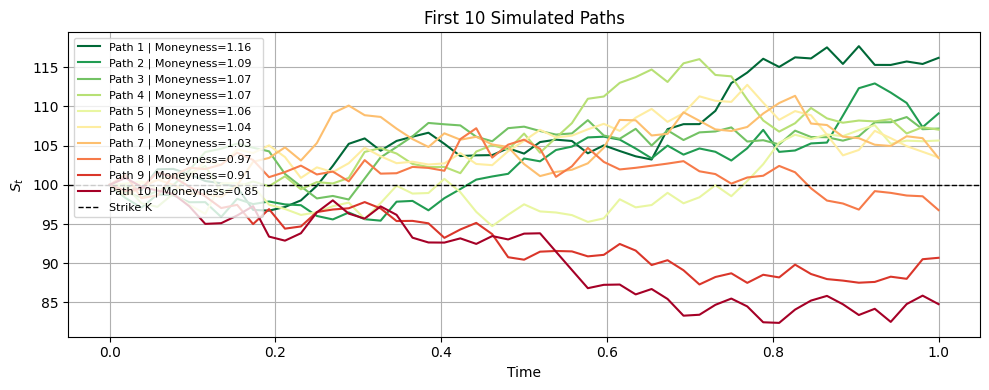

In [77]:
plot_n_paths(S_test, n=10)

In [78]:
def plot_n_deltas(paths, deltas1, deltas2, n, m=0, 
                  name1='deltas1', name2='deltas2'):
    """
    1.Plot the first n paths deltas of the simulated stock prices
    2.Compare deltas
    """
    global K, T

    # --- Sort paths by terminal moneyness, then filter on deltas ---
    first_n = paths[m:n+m,:]
    sort_idx = np.argsort(first_n[:, -1])[::-1]
    first_n = first_n[sort_idx, :]
    terminal_moneyness = first_n[:, -1] / K
    deltas1_n = deltas1[sort_idx, :]
    deltas2_n = deltas2[sort_idx, :]
    
    time_axis = np.linspace(0, T, first_n.shape[1])

    ytick_labels = [f"{terminal_moneyness[i]:.3f}" for i in range(n)]

    # --- Heatmap: deltas1 and deltas2 --- 
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    im1 = axes[0].imshow(deltas1_n, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    axes[0].set_title(name1)
    axes[0].set_xlabel('Time Step')
    axes[0].set_ylabel('Terminal Moneyness $S_T/K$')
    axes[0].set_yticks(range(n))
    axes[0].set_yticklabels(ytick_labels)
    plt.colorbar(im1, ax=axes[0], label='Delta')

    im2 = axes[1].imshow(deltas2_n, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    axes[1].set_title(name2)
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Terminal Moneyness $S_T/K$')
    axes[1].set_yticks(range(n))
    axes[1].set_yticklabels(ytick_labels)
    plt.colorbar(im2, ax=axes[1], label='Delta')

    plt.suptitle(f'Delta Heatmaps - {n} Paths sorted by Terminal Moneyness', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Plot Deltas difference --- 

    # Green: deltas1 > deltas2 | Red: deltas1 < deltas2
    deltas_diff = deltas1_n - deltas2_n
    fig, ax = plt.subplots(figsize=(16, 5))
    im3 = ax.imshow(deltas_diff, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1, origin='upper')
    ax.set_title(f'{name1} - {name2}')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Terminal Moneyness $S_T/K$')
    ax.set_yticks(range(n))
    ax.set_yticklabels(ytick_labels)
    plt.colorbar(im3, ax=ax, label='Delta Difference (green: deltas1 > deltas2 | red: deltas1 < deltas2)')
    plt.suptitle(f'Delta Difference — {n} Paths sorted by Terminal Moneyness (ITM → OTM)', fontsize=13)
    plt.tight_layout()
    plt.show()


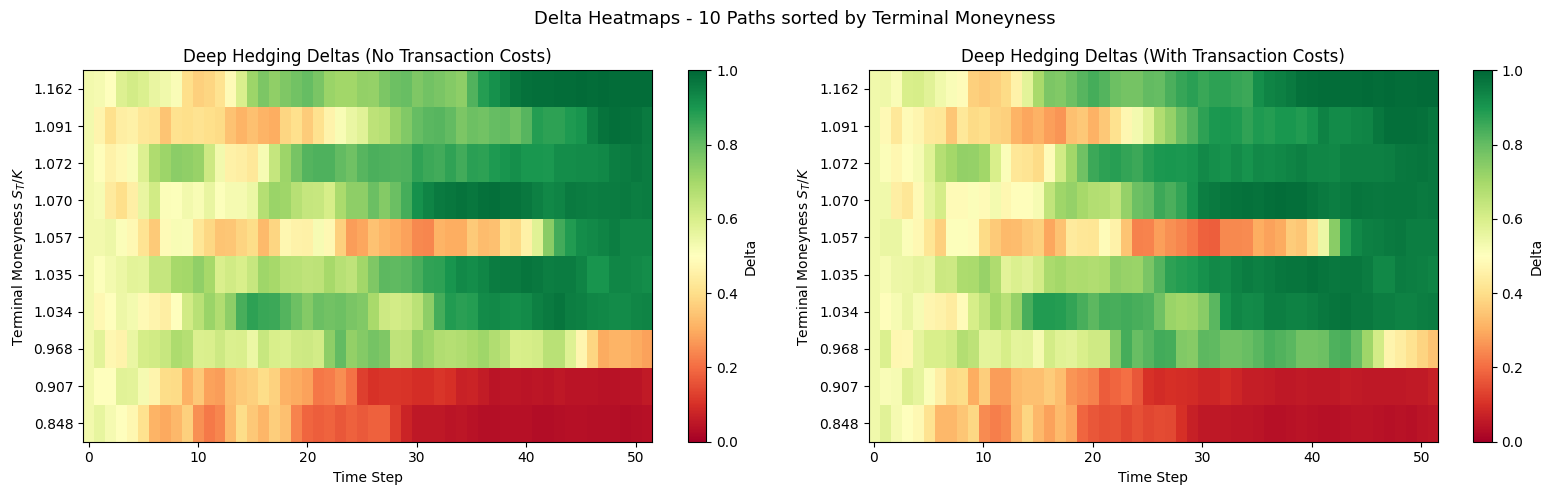

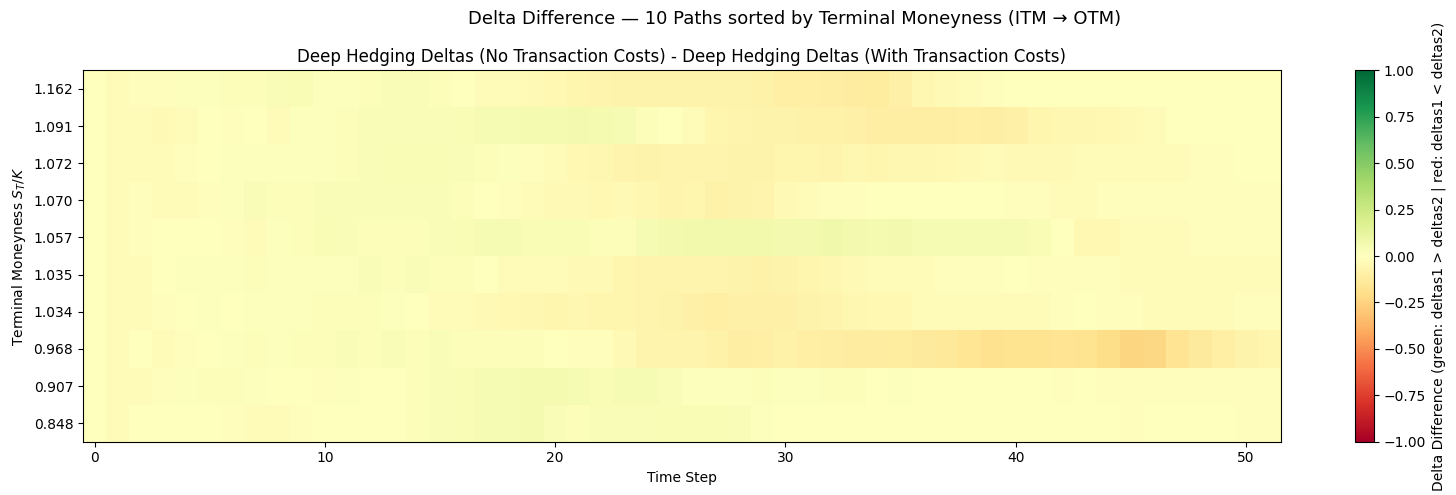

In [79]:
plot_n_deltas(S_test, model_deltas_notc.numpy(), model_deltas_tc.numpy(), n=10, m=0,
              name1='Deep Hedging Deltas (No Transaction Costs)',
              name2='Deep Hedging Deltas (With Transaction Costs)')